In [ ]:
import pandas as pd
import glicko2
import copy
import math
from benchmarks import log_loss, full_benchmark

#from fighters_fights.csv create a dataframe with fighter, date, glicko rating

def rating_func(df_fighters_fights):

    rating_dict = {} # [fighter, date]: glicko rating 
    initialized_fighters = set()

    for i, row in df_fighters_fights.iterrows():
        fighter, opponent, date = row['fighter_name'], row['opponent_name'], row['date']
        if fighter not in initialized_fighters:
            rating_dict[(fighter, date)] = glicko2.Player()
            initialized_fighters.add(fighter)
        if opponent not in initialized_fighters:
            rating_dict[(opponent, date)] = glicko2.Player()
            initialized_fighters.add(opponent)

        last_date = max([d for (f, d) in rating_dict.keys() if f == fighter])
        opp_last_date = max([d for (f, d) in rating_dict.keys() if f == opponent])
        fighter_object = copy.deepcopy(rating_dict[(fighter, last_date)])
        opponent_object = copy.deepcopy(rating_dict[(opponent, opp_last_date)])

        # next two lines in order to freeze variables form objects; makes logic less messy and less variable tracking :)
        fighter_rating, fighter_rd = rating_dict[(fighter, last_date)].rating, rating_dict[(fighter, last_date)].rd
        opponent_rating, opponent_rd = rating_dict[(opponent, opp_last_date)].rating, rating_dict[(opponent, opp_last_date)].rd

        if fighter == row['winner_name']:
            fighter_object.update_player([opponent_rating], [opponent_rd], [1])
            rating_dict[(fighter, date)] = fighter_object
        
            opponent_object.update_player([fighter_rating], [fighter_rd], [0])
            rating_dict[(opponent, date)] = opponent_object
        else:
            fighter_object.update_player([opponent_rating], [opponent_rd], [0])
            rating_dict[(fighter, date)] = fighter_object
        
            opponent_object.update_player([fighter_rating], [fighter_rd], [1])
            rating_dict[(opponent, date)] = opponent_object


    df_ratings = pd.DataFrame(
        [(f, d, p.rating, p.rd, p.vol) for (f, d), p in rating_dict.items()],
        columns=['fighter', 'prior_to_date', 'rating', 'rating_deviation', 'volatility'])

    df_ratings = df_ratings.sort_values(['fighter', 'prior_to_date'], ascending = True)

    # pre-fight rating: the rating carried INTO each fight (previous fight's result)
    df_ratings['rating'] = df_ratings.groupby('fighter')['rating'].shift(1).fillna(1500)
    df_ratings['rating_deviation']     = df_ratings.groupby('fighter')['rating_deviation'].shift(1).fillna(350)
    df_ratings['volatility'] = df_ratings.groupby('fighter')['volatility'].shift(1).fillna(0.06)

    return df_ratings

def outcomes(df_fighters_fights):
    outcomes_list = [] #1 if fighter 1 won, 0 if not
    for i, row in df_fighters_fights.iterrows():
        fighter_1 = row['fighter_name']
        fighter_2 = row['opponent_name']

        if fighter_1 == row['winner_name']:
            outcomes_list.append(1)
        else:
            outcomes_list.append(0)
    return outcomes_list

def prob(r1, d1, r2, d2):
    q = 173.7178
    mu1, mu2 = (r1 - 1500) / q, (r2 - 1500) / q
    phi1, phi2 = d1 / q, d2 / q
    g = 1 / math.sqrt(1 + 3 * (phi1**2 + phi2**2) / math.pi**2)
    prob = 1 / (1 + math.exp(-g * (mu1 - mu2)))
    return prob

def probabilities(df_ratings, df_fighters_fights):
    probabilities = []
    for i, row in df_fighters_fights.iterrows():
        fighter_1 = row['fighter_name']
        fighter_2 = row['opponent_name']
        date = row['date']
    
        row_1 = df_ratings.loc[(df_ratings['fighter'] == fighter_1) & (df_ratings['prior_to_date'] == date)]
        row_2 = df_ratings.loc[(df_ratings['fighter'] == fighter_2) & (df_ratings['prior_to_date'] == date)]

        f1_r, f1_d = row_1['rating'].iloc[0], row_1['rating_deviation'].iloc[0]
        f2_r, f2_d = row_2['rating'].iloc[0], row_2['rating_deviation'].iloc[0]
        probability = prob(f1_r, f1_d, f2_r, f2_d)
    
        probabilities.append(probability)
    return probabilities

def tau_objective(tau, df_fighters_fights):
    glicko2.Player._tau = tau
    outcomes_list = outcomes(df_fighters_fights)
    df_ratings = rating_func(df_fighters_fights)
    probs = probabilities(df_ratings, df_fighters_fights)

    return log_loss(outcomes_list, probs)
#


In [ ]:
folder = '/Users/alejandrogomez-paz/Desktop/UFC Project/2. data_cleaning/fighters_fights.csv'
df = pd.read_csv(folder)
cols = ['round_finished', 'round_time_sec', 'round_total', 'round_time_sec', 'fighter_id', 'event', 'stoppage_time_sec', 'method_type', 'method_specific']
df = df.drop(columns = cols)
df = df[::2]
df = df.sort_values('date', ascending = True)

outcomes_list = outcomes(df)


#bounds come from original paper that gave a more conservative 0.3 - 1.2 range for reasonable Tau values
res = minimize_scalar(tau_objective, bounds=(0.1, 1.4), method='bounded', args=(df,))
optimal_tau = res.x

#print(f'the algorithm converged on the optimal_tau value: {optimal_tau}')
# this line is hardcoded only to prevent from user running the pipeline in the code chunk above; the converged tau value is static
optimal_tau = 0.10040325212871097
glicko2.Player._tau = optimal_tau
df_ratings = rating_func(df)
probs = probabilities(df_ratings, df)

full_benchmark(outcomes_list, probs, 0.05)

df_ratings.to_csv('ratings_instantiation.csv', index = False)


"\nbounds come from original paper that gave a more conservative 0.3 - 1.2 range for reasonable Tau values\nres = minimize_scalar(tau_objective, bounds=(0.1, 1.4), method='bounded', args=(df,))\noptimal_tau = res.x\n"

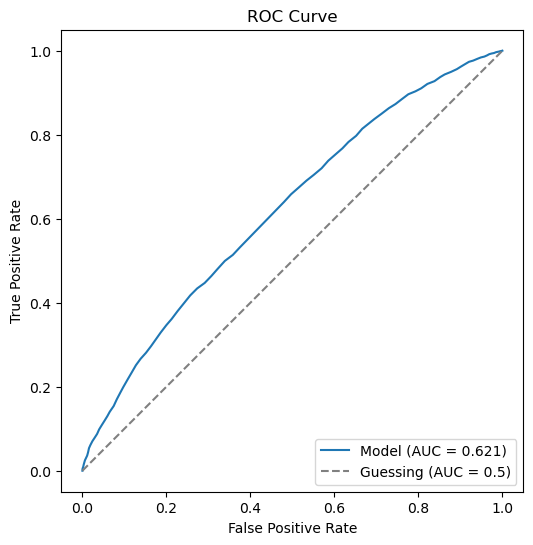

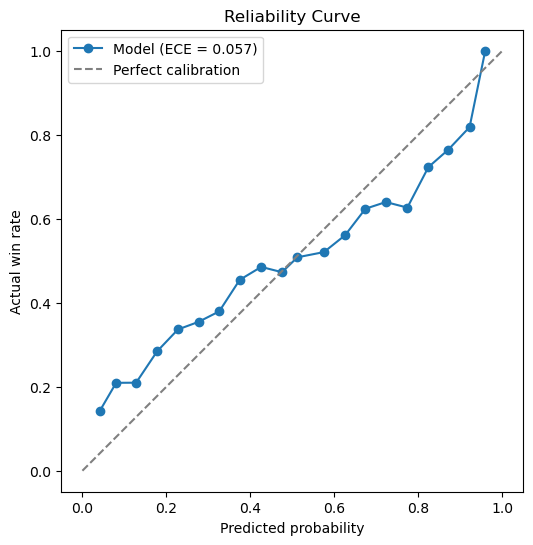

saved glicko_benchmarks.jpeg


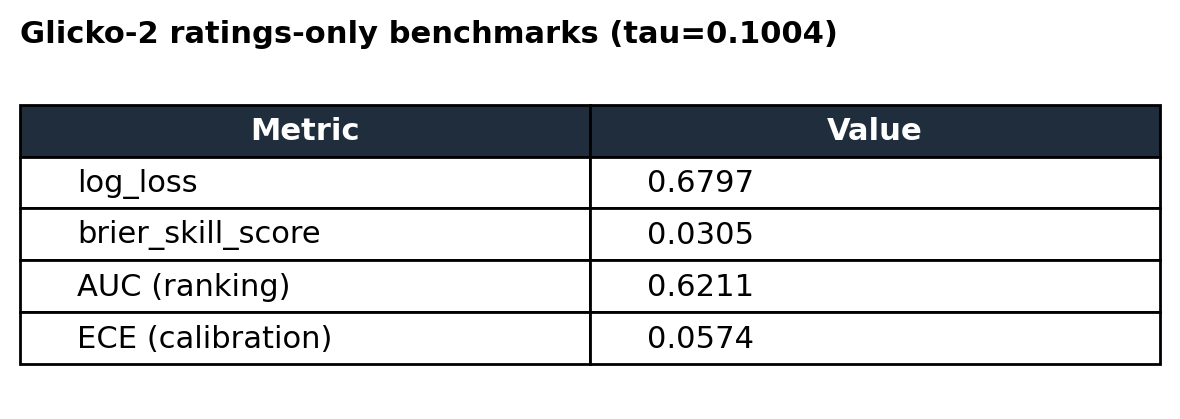

In [11]:
#AI generated jpeg results saver 
from benchmarks import log_loss, brier_skill_score, ranking_calibration, confidence_calibration
import matplotlib.pyplot as plt

# recompute the four metrics as values (ranking/confidence also pop up their plots)
metrics = {
    "log_loss":            log_loss(outcomes_list, probs),
    "brier_skill_score":   brier_skill_score(outcomes_list, probs),
    "AUC (ranking)":       ranking_calibration(outcomes_list, probs),
    "ECE (calibration)":   confidence_calibration(outcomes_list, probs, 0.05),
}

fig, ax = plt.subplots(figsize=(6, 2.2), dpi=200)
ax.axis("off")
ax.set_title(f"Glicko-2 ratings-only benchmarks (tau={optimal_tau:.4f})",
             fontsize=11, fontweight="bold", loc="left", pad=10)
tbl = ax.table(
    cellText=[[k, f"{v:.4f}"] for k, v in metrics.items()],
    colLabels=["Metric", "Value"], cellLoc="left", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.6)
for j in range(2):
    tbl[0, j].set_facecolor("#1f2d3d"); tbl[0, j].set_text_props(color="white", fontweight="bold")

fig.tight_layout()
fig.savefig("glicko_benchmarks.jpeg", dpi=200, bbox_inches="tight", facecolor="white")
print("saved glicko_benchmarks.jpeg")